# COIL-100 pose manifold experiment with DINOv2 image embeddings

This notebook tests whether an image embedding space preserves a known physical image manifold: **object rotation angle** in COIL-100.

The core question is deliberately simple, because apparently science occasionally benefits from not juggling flaming confounds:

> For images of the same object taken at different rotation angles, does distance in DINOv2 embedding space increase with circular pose-angle distance?

## Dataset

COIL-100 contains 7,200 colour images: 100 objects × 72 poses. Objects were placed on a turntable and imaged every 5 degrees over a full 360-degree rotation. The notebook downloads the processed archive from Columbia CAVE if it is not already present.

Primary references:

- COIL-100 homepage: https://www.cs.columbia.edu/CAVE/software/softlib/coil-100.php
- TensorFlow Datasets metadata: https://www.tensorflow.org/datasets/catalog/coil100

## Embedding model

Primary model: `facebook/dinov2-base` from Hugging Face Transformers.

DINOv2 is used because this is a visual feature extraction problem, not a caption-geometry problem wearing fake glasses. The notebook extracts the `[CLS]` token representation and L2-normalises it before distance calculations.

Model reference:

- https://huggingface.co/facebook/dinov2-base


## Methodology summary

1. **Index images** from COIL-100 filenames of the form `obj{object_id}__{angle}.png`.
2. **Embed each image** using DINOv2 ViT-B/14 via `AutoImageProcessor` and `AutoModel`.
3. **Normalise embeddings** to unit length.
4. For each object separately, compute:
   - representation distance: angular distance between image embeddings;
   - ground-truth distance: circular angle distance, where 0° and 355° are 5° apart, not enemies separated by a bureaucratic wall.
5. Compare representation distances and ground-truth distances with **Spearman**, **Pearson**, and **Kendall** correlations.
6. Build a **symmetric k-nearest-neighbour graph** in embedding space and compute shortest-path geodesic distances, using the smallest `k` that makes the graph connected up to `K_MAX`.
7. Run within-object **permutation controls** by shuffling the pose angles and recomputing the ground-truth distances.
8. Save object-level results, summary tables, and plots.

Primary statistic: median object-level Spearman correlation between embedding distance and circular pose distance.


## Setup

Run the install cell only if your environment is missing packages. In VSCode on Windows, create/select a virtual environment first, because otherwise Python dependency management becomes a tiny municipal disaster.


In [1]:
# Optional dependency install. Uncomment in a fresh environment.
# %pip install -q numpy pandas pillow matplotlib scikit-learn scipy torch torchvision transformers tqdm


In [2]:
from __future__ import annotations

import math
import os
import re
import time
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.stats import kendalltau, pearsonr, spearmanr
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

try:
    import torch
except ImportError as exc:
    raise ImportError("Install torch before running this notebook: pip install torch torchvision") from exc

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

PROJECT_DIR = Path("coil100_pose_manifold")
DATA_DIR = PROJECT_DIR / "data"
OUT_DIR = PROJECT_DIR / "outputs"
PLOT_DIR = OUT_DIR / "plots"
for d in [DATA_DIR, OUT_DIR, PLOT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

COIL_ZIP_URL = "https://www.cs.columbia.edu/CAVE/databases/SLAM_coil-20_coil-100/coil-100/coil-100.zip"
ZIP_PATH = DATA_DIR / "coil-100.zip"
EXTRACT_DIR = DATA_DIR / "coil-100-extracted"

MODEL_NAME = "facebook/dinov2-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 64 if DEVICE == "cuda" else 16

# Set these to smaller values for a fast debugging run.
MAX_OBJECTS = None             # e.g. 10 for quick test, None for all 100
MAX_IMAGES_PER_OBJECT = None   # e.g. 72, None for all poses
N_PERMUTATIONS = 200
K_MAX = 24

EMBEDDINGS_PATH = OUT_DIR / "dinov2_base_cls_embeddings.npy"
METADATA_PATH = OUT_DIR / "coil100_metadata_for_embeddings.csv"
RESULTS_PATH = OUT_DIR / "object_level_pose_alignment.csv"
SUMMARY_PATH = OUT_DIR / "pose_alignment_summary.csv"

print("Device:", DEVICE)
print("Batch size:", BATCH_SIZE)
print("Project directory:", PROJECT_DIR.resolve())


def l2_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    X = np.asarray(X)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)


Device: cuda
Batch size: 64
Project directory: D:\pyprojects\m4r\coil100_pose_manifold


d:\pyprojects\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Distance and manifold analysis helpers

The ground-truth metric is circular pose distance:

\[
 d_{pose}(a,b)=\frac{\min(|a-b|, 360-|a-b|)}{180}
\]

The representation metric is angular embedding distance:

\[
 d_{emb}(x_i,x_j)=\frac{\arccos(\mathrm{clip}(\hat{x}_i \cdot \hat{x}_j, -1, 1))}{\pi}
\]

Both are normalised to roughly `[0, 1]` for readability. Correlations do not care about this scaling, but humans do, tragically.


In [3]:
def upper_values(D: np.ndarray) -> np.ndarray:
    idx = np.triu_indices(D.shape[0], k=1)
    return D[idx]


def angular_distance_matrix(X: np.ndarray) -> np.ndarray:
    Xn = l2_normalize(np.asarray(X, dtype=np.float64))
    sims = np.clip(Xn @ Xn.T, -1.0, 1.0)
    return np.arccos(sims) / np.pi


def circular_angle_distance_matrix(angles: np.ndarray, period: float = 360.0) -> np.ndarray:
    a = np.asarray(angles, dtype=float).reshape(-1, 1)
    diff = np.abs(a - a.T)
    return np.minimum(diff, period - diff) / (period / 2.0)


def corr_stats(x: np.ndarray, y: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 3 or np.std(x) == 0 or np.std(y) == 0:
        return {
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_rho": np.nan,
            "spearman_p": np.nan,
            "kendall_tau": np.nan,
            "kendall_p": np.nan,
            "n_pairs": int(len(x)),
        }
    pr = pearsonr(x, y)
    sr = spearmanr(x, y)
    kt = kendalltau(x, y)
    return {
        "pearson_r": float(pr.statistic),
        "pearson_p": float(pr.pvalue),
        "spearman_rho": float(sr.statistic),
        "spearman_p": float(sr.pvalue),
        "kendall_tau": float(kt.statistic),
        "kendall_p": float(kt.pvalue),
        "n_pairs": int(len(x)),
    }


def symmetric_knn_graph_from_distance(D: np.ndarray, k: int) -> csr_matrix:
    n = D.shape[0]
    if not 1 <= k < n:
        raise ValueError(f"k must be in [1, n-1]; got k={k}, n={n}")
    indices = np.argsort(D, axis=1)[:, 1:k + 1]
    rows = np.repeat(np.arange(n), k)
    cols = indices.reshape(-1)
    vals = D[rows, cols]
    G = csr_matrix((vals, (rows, cols)), shape=(n, n))
    return G.maximum(G.T)


def connected_geodesic_from_distance(D: np.ndarray, k_max: int = 24) -> tuple[np.ndarray, int, int]:
    n = D.shape[0]
    upper_k = min(k_max, n - 1)
    last_components = None
    for k in range(1, upper_k + 1):
        G = symmetric_knn_graph_from_distance(D, k)
        n_components, _ = connected_components(G, directed=False)
        last_components = int(n_components)
        if n_components == 1:
            geo = dijkstra(G, directed=False, return_predecessors=False)
            return geo, k, int(n_components)

    # Fall back to the densest tried graph. Results are marked as disconnected.
    G = symmetric_knn_graph_from_distance(D, upper_k)
    geo = dijkstra(G, directed=False, return_predecessors=False)
    return geo, upper_k, int(last_components or -1)


def permutation_pvalue(
    observed_abs_rho: float,
    rep_upper: np.ndarray,
    angles: np.ndarray,
    n_perm: int,
    seed: int,
) -> float:
    if n_perm <= 0 or not np.isfinite(observed_abs_rho):
        return np.nan
    rng_local = np.random.default_rng(seed)
    count = 0
    for _ in range(n_perm):
        shuffled = rng_local.permutation(angles)
        D_gt_perm = circular_angle_distance_matrix(shuffled)
        rho = corr_stats(upper_values(D_gt_perm), rep_upper)["spearman_rho"]
        if np.isfinite(rho) and abs(rho) >= observed_abs_rho:
            count += 1
    return float((count + 1) / (n_perm + 1))


def analyze_single_object(
    X_obj: np.ndarray,
    angles: np.ndarray,
    object_id: int | str,
    n_perm: int = 200,
    k_max: int = 24,
    seed: int = 42,
) -> dict:
    D_gt = circular_angle_distance_matrix(angles)
    gt_upper = upper_values(D_gt)

    D_emb = angular_distance_matrix(X_obj)
    emb_upper = upper_values(D_emb)
    direct = corr_stats(gt_upper, emb_upper)
    direct_p_perm = permutation_pvalue(
        abs(direct["spearman_rho"]), emb_upper, angles, n_perm=n_perm, seed=seed + int(object_id)
    )

    D_geo, k_used, n_components = connected_geodesic_from_distance(D_emb, k_max=k_max)
    geo_upper = upper_values(D_geo)
    geodesic = corr_stats(gt_upper, geo_upper)
    geodesic_p_perm = permutation_pvalue(
        abs(geodesic["spearman_rho"]), geo_upper, angles, n_perm=n_perm, seed=seed + 10_000 + int(object_id)
    )

    return {
        "object_id": object_id,
        "n_images": int(len(angles)),
        "direct_angular_spearman": direct["spearman_rho"],
        "direct_angular_pearson": direct["pearson_r"],
        "direct_angular_kendall": direct["kendall_tau"],
        "direct_angular_p_perm_abs_spearman": direct_p_perm,
        "geodesic_angular_spearman": geodesic["spearman_rho"],
        "geodesic_angular_pearson": geodesic["pearson_r"],
        "geodesic_angular_kendall": geodesic["kendall_tau"],
        "geodesic_angular_p_perm_abs_spearman": geodesic_p_perm,
        "geodesic_knn_k": int(k_used),
        "geodesic_connected_components": int(n_components),
        "n_pairs": direct["n_pairs"],
    }


def run_object_level_analysis(
    X: np.ndarray,
    meta: pd.DataFrame,
    n_perm: int,
    k_max: int,
    seed: int,
) -> pd.DataFrame:
    if len(X) != len(meta):
        raise ValueError(f"Embedding and metadata lengths differ: {len(X)} vs {len(meta)}")

    rows = []
    meta_work = meta.reset_index(drop=True).copy()
    meta_work["_row"] = np.arange(len(meta_work))

    for object_id, group in tqdm(list(meta_work.groupby("object_id")), desc="Objects"):
        group = group.sort_values("angle")
        idx = group["_row"].to_numpy()
        X_obj = X[idx]
        angles = group["angle"].to_numpy()
        if len(np.unique(angles)) < 6:
            print(f"Skipping object {object_id}: too few unique angles")
            continue
        rows.append(
            analyze_single_object(
                X_obj=X_obj,
                angles=angles,
                object_id=int(object_id),
                n_perm=n_perm,
                k_max=k_max,
                seed=seed,
            )
        )
    return pd.DataFrame(rows).sort_values("object_id").reset_index(drop=True)


## Smoke test for the analysis code

This does **not** use COIL-100. It creates a toy circular manifold, then verifies that the analysis detects it. Useful before spending compute on real embeddings, because debugging after 7,200 model calls is how people become folklore villains.


In [4]:
def smoke_test_pose_analysis(noise: float = 0.03) -> pd.Series:
    angles = np.arange(0, 360, 5)
    theta = np.deg2rad(angles)
    X_circle = np.column_stack([
        np.cos(theta),
        np.sin(theta),
        0.5 * np.cos(2 * theta),
        0.5 * np.sin(2 * theta),
    ])
    X_circle = X_circle + np.random.default_rng(123).normal(scale=noise, size=X_circle.shape)
    X_circle = l2_normalize(X_circle)
    res = analyze_single_object(X_circle, angles, object_id=1, n_perm=50, k_max=8, seed=123)
    return pd.Series(res)

smoke = smoke_test_pose_analysis()
smoke


object_id                                  1.000000
n_images                                  72.000000
direct_angular_spearman                    0.982176
direct_angular_pearson                     0.952241
direct_angular_kendall                     0.918184
direct_angular_p_perm_abs_spearman         0.019608
geodesic_angular_spearman                  0.999257
geodesic_angular_pearson                   0.999277
geodesic_angular_kendall                   0.981920
geodesic_angular_p_perm_abs_spearman       0.019608
geodesic_knn_k                             2.000000
geodesic_connected_components              1.000000
n_pairs                                 2556.000000
dtype: float64

## Download and index COIL-100

The official archive is about 125 MB. If your institution/network blocks direct download, manually download `coil-100.zip` from the COIL-100 homepage and place it at:

```text
coil100_pose_manifold/data/coil-100.zip
```


In [5]:
def download_file(url: str, dst: Path) -> None:
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size > 0:
        print(f"Already downloaded: {dst} ({dst.stat().st_size / 1e6:.1f} MB)")
        return

    print(f"Downloading {url}\n -> {dst}")
    try:
        with urllib.request.urlopen(url, timeout=60) as response:
            total = response.headers.get("Content-Length")
            total = int(total) if total else None
            block_size = 1024 * 1024
            downloaded = 0
            start = time.time()
            with open(dst, "wb") as f:
                while True:
                    block = response.read(block_size)
                    if not block:
                        break
                    f.write(block)
                    downloaded += len(block)
                    if total:
                        pct = downloaded / total * 100
                        print(f"\r{downloaded / 1e6:.1f}/{total / 1e6:.1f} MB ({pct:.1f}%)", end="")
            print(f"\nDone in {time.time() - start:.1f}s")
    except Exception as exc:
        raise RuntimeError(
            "Could not download COIL-100 automatically. "
            "Manually download coil-100.zip from the official COIL-100 page and place it at "
            f"{dst.resolve()}"
        ) from exc


def extract_zip_if_needed(zip_path: Path, extract_dir: Path) -> None:
    image_files = list(extract_dir.rglob("obj*__*.png")) if extract_dir.exists() else []
    if image_files:
        print(f"Already extracted: found {len(image_files)} image files")
        return
    if not zip_path.exists():
        raise FileNotFoundError(zip_path)
    extract_dir.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {zip_path} -> {extract_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Extraction complete")


def build_coil100_index(image_root: Path) -> pd.DataFrame:
    pattern = re.compile(r"obj(?P<object_id>\d+)__(?P<angle>\d+)\.(png|jpg|jpeg|ppm)$", re.IGNORECASE)
    rows = []
    for path in sorted(image_root.rglob("*")):
        if not path.is_file():
            continue
        match = pattern.match(path.name)
        if not match:
            continue
        object_id = int(match.group("object_id"))
        angle = int(match.group("angle"))
        rows.append({
            "image_path": str(path),
            "object_id": object_id,
            "angle": angle,
            "angle_label": angle // 5,
        })
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f"No COIL-style image filenames found under {image_root.resolve()}")
    df = df.sort_values(["object_id", "angle"]).reset_index(drop=True)
    return df


download_file(COIL_ZIP_URL, ZIP_PATH)
extract_zip_if_needed(ZIP_PATH, EXTRACT_DIR)
metadata_all = build_coil100_index(EXTRACT_DIR)

print(metadata_all.head())
print("Images indexed:", len(metadata_all))
print("Objects:", metadata_all["object_id"].nunique())
print("Angles per object, min/max:", metadata_all.groupby("object_id")["angle"].nunique().min(), metadata_all.groupby("object_id")["angle"].nunique().max())

if len(metadata_all) != 7200:
    print("Warning: expected 7,200 images for full COIL-100. Check extraction/download before trusting results.")


Already downloaded: coil100_pose_manifold\data\coil-100.zip (130.7 MB)
Already extracted: found 7200 image files
                                          image_path  object_id  angle  \
0  coil100_pose_manifold\data\coil-100-extracted\...          1      0   
1  coil100_pose_manifold\data\coil-100-extracted\...          1      5   
2  coil100_pose_manifold\data\coil-100-extracted\...          1     10   
3  coil100_pose_manifold\data\coil-100-extracted\...          1     15   
4  coil100_pose_manifold\data\coil-100-extracted\...          1     20   

   angle_label  
0            0  
1            1  
2            2  
3            3  
4            4  
Images indexed: 7200
Objects: 100
Angles per object, min/max: 72 72


In [6]:
def apply_debug_subsampling(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if MAX_OBJECTS is not None:
        keep_objects = sorted(out["object_id"].unique())[: int(MAX_OBJECTS)]
        out = out[out["object_id"].isin(keep_objects)].copy()
    if MAX_IMAGES_PER_OBJECT is not None:
        out = (
            out.groupby("object_id", group_keys=False)
            .apply(lambda g: g.sort_values("angle").head(int(MAX_IMAGES_PER_OBJECT)))
            .reset_index(drop=True)
        )
    out = out.sort_values(["object_id", "angle"]).reset_index(drop=True)
    return out

metadata = apply_debug_subsampling(metadata_all)
metadata.to_csv(OUT_DIR / "coil100_index_selected.csv", index=False)
print("Selected images:", len(metadata))
print("Selected objects:", metadata["object_id"].nunique())
metadata.head()


Selected images: 7200
Selected objects: 100


,image_path,object_id,angle,angle_label
0,coil100_pose_manifold\data\coil-100-extracted\...,1,0,0
1,coil100_pose_manifold\data\coil-100-extracted\...,1,5,1
2,coil100_pose_manifold\data\coil-100-extracted\...,1,10,2
3,coil100_pose_manifold\data\coil-100-extracted\...,1,15,3
4,coil100_pose_manifold\data\coil-100-extracted\...,1,20,4


## Embed images with DINOv2

This cell caches embeddings. If `dinov2_base_cls_embeddings.npy` and the matching metadata CSV already exist, it loads them instead of re-embedding. A GPU is helpful but not mandatory. CPU will work, in the same way a teaspoon technically works for digging a garden.


In [7]:
def load_rgb(path: str | Path) -> Image.Image:
    return Image.open(path).convert("RGB")


def embed_images_dinov2(
    df: pd.DataFrame,
    model_name: str,
    batch_size: int,
    device: str,
    embeddings_path: Path,
    metadata_path: Path,
) -> tuple[np.ndarray, pd.DataFrame]:
    if embeddings_path.exists() and metadata_path.exists():
        X = np.load(embeddings_path)
        meta = pd.read_csv(metadata_path)
        if len(X) == len(meta):
            print(f"Loaded cached embeddings: {embeddings_path} {X.shape}")
            return X, meta
        print("Cached embeddings and metadata length mismatch. Re-embedding.")

    try:
        from transformers import AutoImageProcessor, AutoModel
    except ImportError as exc:
        raise ImportError("Install transformers first: pip install transformers") from exc

    print(f"Loading {model_name} on {device}")
    processor = AutoImageProcessor.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.to(device)
    model.eval()

    vectors = []
    paths = df["image_path"].tolist()

    with torch.inference_mode():
        for start in tqdm(range(0, len(paths), batch_size), desc="Embedding images"):
            batch_paths = paths[start:start + batch_size]
            images = [load_rgb(p) for p in batch_paths]
            inputs = processor(images=images, return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)

            # DINOv2's [CLS] token is the first token in last_hidden_state.
            cls = outputs.last_hidden_state[:, 0, :]
            vectors.append(cls.detach().cpu().numpy())

    X = np.vstack(vectors).astype(np.float32)
    X = l2_normalize(X).astype(np.float32)

    meta = df.reset_index(drop=True).copy()
    meta["embedding_model"] = model_name
    meta["embedding_type"] = "last_hidden_state_cls_l2_normalized"
    meta.to_csv(metadata_path, index=False)
    np.save(embeddings_path, X)
    print(f"Saved embeddings: {embeddings_path} {X.shape}")
    print(f"Saved metadata: {metadata_path}")
    return X, meta


X, meta = embed_images_dinov2(
    df=metadata,
    model_name=MODEL_NAME,
    batch_size=BATCH_SIZE,
    device=DEVICE,
    embeddings_path=EMBEDDINGS_PATH,
    metadata_path=METADATA_PATH,
)

print(X.shape)
meta.head()


Loaded cached embeddings: coil100_pose_manifold\outputs\dinov2_base_cls_embeddings.npy (7200, 768)
(7200, 768)


,image_path,object_id,angle,angle_label,embedding_model,embedding_type
0,coil100_pose_manifold\data\coil-100-extracted\...,1,0,0,facebook/dinov2-base,last_hidden_state_cls_l2_normalized
1,coil100_pose_manifold\data\coil-100-extracted\...,1,5,1,facebook/dinov2-base,last_hidden_state_cls_l2_normalized
2,coil100_pose_manifold\data\coil-100-extracted\...,1,10,2,facebook/dinov2-base,last_hidden_state_cls_l2_normalized
3,coil100_pose_manifold\data\coil-100-extracted\...,1,15,3,facebook/dinov2-base,last_hidden_state_cls_l2_normalized
4,coil100_pose_manifold\data\coil-100-extracted\...,1,20,4,facebook/dinov2-base,last_hidden_state_cls_l2_normalized


## Run the COIL-100 object-level analysis

The analysis is deliberately **within-object**. Across-object distances mostly test object identity, not pose geometry. Pretending otherwise would be a very efficient way to confuse yourself with confidence.


In [10]:
results = run_object_level_analysis(
    X=X,
    meta=meta,
    n_perm=N_PERMUTATIONS,
    k_max=K_MAX,
    seed=RANDOM_SEED,
)
results.to_csv(RESULTS_PATH, index=False)
print(f"Saved: {RESULTS_PATH}")
results.head()


Objects: 100%|██████████| 100/100 [01:25<00:00,  1.17it/s]

Saved: coil100_pose_manifold\outputs\object_level_pose_alignment.csv


,object_id,n_images,direct_angular_spearman,direct_angular_pearson,direct_angular_kendall,direct_angular_p_perm_abs_spearman,geodesic_angular_spearman,geodesic_angular_pearson,geodesic_angular_kendall,geodesic_angular_p_perm_abs_spearman,geodesic_knn_k,geodesic_connected_components,n_pairs
0,1,72,0.305909,0.326683,0.203229,0.004975,0.977185,0.975939,0.877749,0.004975,2,1,2556
1,2,72,0.707360,0.730730,0.528977,0.004975,0.734596,0.609289,0.620824,0.004975,3,1,2556
2,3,72,0.350094,0.403062,0.244361,0.004975,0.993985,0.994009,0.940688,0.004975,2,1,2556
3,4,72,0.447259,0.450291,0.317908,0.004975,0.978717,0.978598,0.879678,0.004975,3,1,2556
4,5,72,0.806662,0.810851,0.629090,0.004975,0.733962,0.584574,0.619923,0.004975,3,1,2556


In [11]:
def summarize_results(results: pd.DataFrame) -> pd.DataFrame:
    metrics = [
        "direct_angular_spearman",
        "direct_angular_pearson",
        "direct_angular_kendall",
        "geodesic_angular_spearman",
        "geodesic_angular_pearson",
        "geodesic_angular_kendall",
        "geodesic_knn_k",
    ]
    rows = []
    for col in metrics:
        s = pd.to_numeric(results[col], errors="coerce").dropna()
        if s.empty:
            continue
        rows.append({
            "metric": col,
            "n_objects": int(s.shape[0]),
            "mean": float(s.mean()),
            "std": float(s.std(ddof=1)) if len(s) > 1 else np.nan,
            "median": float(s.median()),
            "q25": float(s.quantile(0.25)),
            "q75": float(s.quantile(0.75)),
            "min": float(s.min()),
            "max": float(s.max()),
        })
    return pd.DataFrame(rows)

summary = summarize_results(results)
summary.to_csv(SUMMARY_PATH, index=False)
print(f"Saved: {SUMMARY_PATH}")
summary


Saved: coil100_pose_manifold\outputs\pose_alignment_summary.csv


,metric,n_objects,mean,std,median,q25,q75,min,max
0,direct_angular_spearman,100,0.457609,0.187457,0.449826,0.305399,0.623324,0.053942,0.806662
1,direct_angular_pearson,100,0.472592,0.188657,0.465956,0.319841,0.641731,0.057117,0.810851
2,direct_angular_kendall,100,0.330757,0.148093,0.313486,0.202943,0.467423,0.031005,0.629090
3,geodesic_angular_spearman,100,0.778593,0.153056,0.736104,0.698827,0.958947,0.293359,0.995435
4,geodesic_angular_pearson,100,0.732071,0.180664,0.640514,0.595221,0.958509,0.323357,0.995418
5,geodesic_angular_kendall,100,0.656650,0.167016,0.618895,0.547915,0.830702,0.192194,0.949806
6,geodesic_knn_k,100,2.720000,0.753175,3.000000,2.000000,3.000000,2.000000,7.000000


## Plot results

These figures are saved in `coil100_pose_manifold/outputs/plots/`.


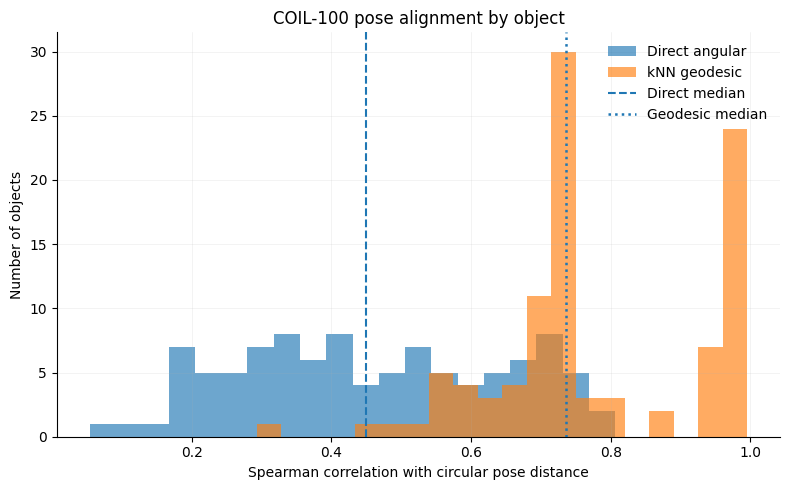

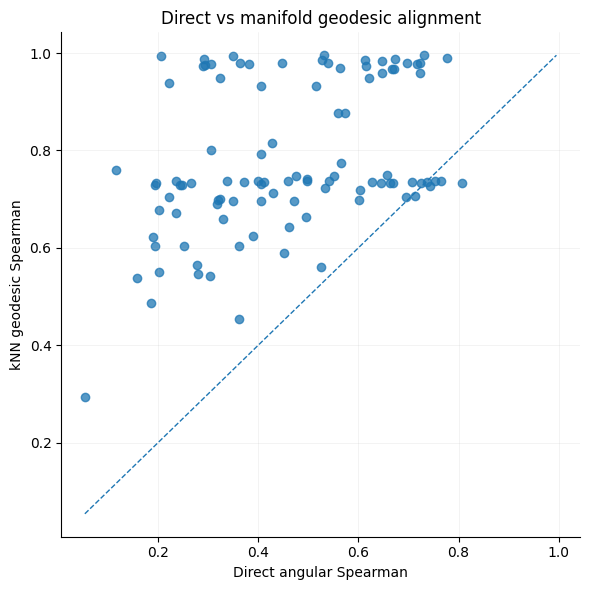

In [12]:
def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linewidth=0.4, alpha=0.25)


def save_histograms(results: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(results["direct_angular_spearman"].dropna(), bins=20, alpha=0.65, label="Direct angular")
    ax.hist(results["geodesic_angular_spearman"].dropna(), bins=20, alpha=0.65, label="kNN geodesic")
    ax.axvline(results["direct_angular_spearman"].median(), linestyle="--", linewidth=1.5, label="Direct median")
    ax.axvline(results["geodesic_angular_spearman"].median(), linestyle=":", linewidth=1.8, label="Geodesic median")
    ax.set_xlabel("Spearman correlation with circular pose distance")
    ax.set_ylabel("Number of objects")
    ax.set_title("COIL-100 pose alignment by object")
    ax.legend(frameon=False)
    clean_axes(ax)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / "spearman_histogram_direct_vs_geodesic.png", dpi=220)
    plt.show()


def save_direct_vs_geodesic_scatter(results: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(results["direct_angular_spearman"], results["geodesic_angular_spearman"], alpha=0.75)
    lo = np.nanmin(results[["direct_angular_spearman", "geodesic_angular_spearman"]].to_numpy())
    hi = np.nanmax(results[["direct_angular_spearman", "geodesic_angular_spearman"]].to_numpy())
    ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
    ax.set_xlabel("Direct angular Spearman")
    ax.set_ylabel("kNN geodesic Spearman")
    ax.set_title("Direct vs manifold geodesic alignment")
    clean_axes(ax)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / "direct_vs_geodesic_spearman.png", dpi=220)
    plt.show()


save_histograms(results)
save_direct_vs_geodesic_scatter(results)


Example object: 4


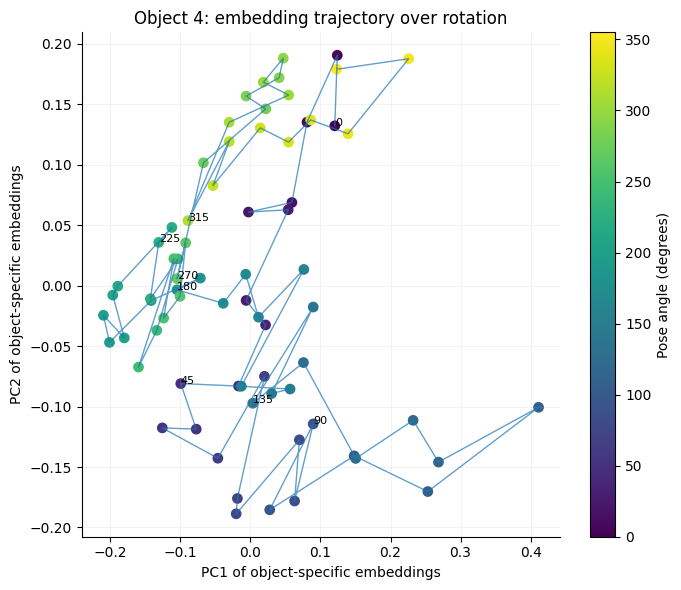

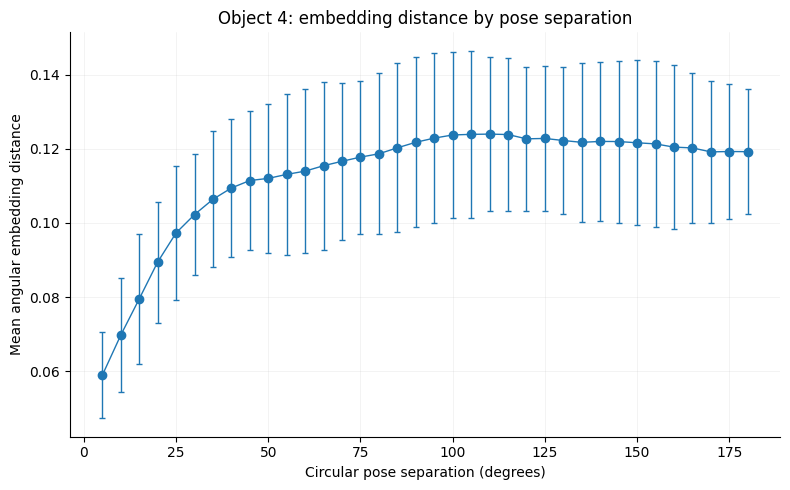

In [13]:
def plot_object_embedding_loop(object_id: int, X: np.ndarray, meta: pd.DataFrame) -> None:
    meta_work = meta.reset_index(drop=True).copy()
    meta_work["_row"] = np.arange(len(meta_work))
    group = meta_work[meta_work["object_id"].eq(object_id)].sort_values("angle")
    if group.empty:
        raise ValueError(f"Object {object_id} not found")

    idx = group["_row"].to_numpy()
    X_obj = X[idx]
    angles = group["angle"].to_numpy()

    Z = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X_obj)

    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=angles, s=45)
    ax.plot(Z[:, 0], Z[:, 1], linewidth=1, alpha=0.7)
    for x, y, angle in zip(Z[:, 0], Z[:, 1], angles):
        if angle % 45 == 0:
            ax.text(x, y, str(int(angle)), fontsize=8)
    fig.colorbar(sc, ax=ax, label="Pose angle (degrees)")
    ax.set_xlabel("PC1 of object-specific embeddings")
    ax.set_ylabel("PC2 of object-specific embeddings")
    ax.set_title(f"Object {object_id}: embedding trajectory over rotation")
    clean_axes(ax)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"object_{object_id:03d}_pca_rotation_loop.png", dpi=220)
    plt.show()


def plot_distance_curve(object_id: int, X: np.ndarray, meta: pd.DataFrame) -> None:
    meta_work = meta.reset_index(drop=True).copy()
    meta_work["_row"] = np.arange(len(meta_work))
    group = meta_work[meta_work["object_id"].eq(object_id)].sort_values("angle")
    idx = group["_row"].to_numpy()
    X_obj = X[idx]
    angles = group["angle"].to_numpy()

    D_emb = angular_distance_matrix(X_obj)
    D_gt_degrees = circular_angle_distance_matrix(angles) * 180.0
    sep = upper_values(D_gt_degrees)
    dist = upper_values(D_emb)

    curve = pd.DataFrame({"angle_separation": sep, "embedding_distance": dist})
    curve = curve.groupby("angle_separation")["embedding_distance"].agg(["mean", "std", "count"]).reset_index()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(curve["angle_separation"], curve["mean"], yerr=curve["std"], marker="o", linewidth=1, capsize=2)
    ax.set_xlabel("Circular pose separation (degrees)")
    ax.set_ylabel("Mean angular embedding distance")
    ax.set_title(f"Object {object_id}: embedding distance by pose separation")
    clean_axes(ax)
    fig.tight_layout()
    fig.savefig(PLOT_DIR / f"object_{object_id:03d}_distance_curve.png", dpi=220)
    plt.show()


# Pick a representative object near the median direct Spearman, unless you override it.
median_ranked = results.assign(_delta=(results["direct_angular_spearman"] - results["direct_angular_spearman"].median()).abs())
EXAMPLE_OBJECT_ID = int(median_ranked.sort_values("_delta").iloc[0]["object_id"])
print("Example object:", EXAMPLE_OBJECT_ID)
plot_object_embedding_loop(EXAMPLE_OBJECT_ID, X, meta)
plot_distance_curve(EXAMPLE_OBJECT_ID, X, meta)


In [14]:
# 3D Plotly visualisations for object 4:
# 1. Embedding rotation loop in the first 3 object-specific PCA dimensions
# 2. Distance curve using circular pose separation, angular embedding distance, and PCA-3 chord distance

import plotly.graph_objects as go
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

EXAMPLE_OBJECT_ID = 4


def object_subset_with_pca3(object_id: int, X: np.ndarray, meta: pd.DataFrame):
    """Return sorted metadata and first 3 object-specific PCA coordinates."""
    meta_work = meta.reset_index(drop=True).copy()
    meta_work["_row"] = np.arange(len(meta_work))

    group = (
        meta_work[meta_work["object_id"].eq(object_id)]
        .sort_values("angle")
        .reset_index(drop=True)
    )

    if group.empty:
        raise ValueError(f"Object {object_id} was not found in metadata.")

    idx = group["_row"].to_numpy()
    X_obj = X[idx]
    angles = group["angle"].to_numpy()

    if min(X_obj.shape[0], X_obj.shape[1]) < 3:
        raise ValueError("Need at least 3 PCA components for a 3D plot.")

    pca = PCA(n_components=3, random_state=RANDOM_SEED)
    Z = pca.fit_transform(X_obj)

    group["pc1"] = Z[:, 0]
    group["pc2"] = Z[:, 1]
    group["pc3"] = Z[:, 2]

    group["hover"] = [
        (
            f"object={object_id}<br>"
            f"angle={int(angle)}°<br>"
            f"PC1={pc1:.4f}<br>"
            f"PC2={pc2:.4f}<br>"
            f"PC3={pc3:.4f}"
        )
        for angle, pc1, pc2, pc3 in zip(angles, Z[:, 0], Z[:, 1], Z[:, 2])
    ]

    return group, angles, Z, pca.explained_variance_ratio_


def plot_object_embedding_loop_3d(object_id: int, X: np.ndarray, meta: pd.DataFrame):
    """Plot the rotation trajectory of one object in 3D PCA space."""
    group, angles, Z, explained = object_subset_with_pca3(object_id, X, meta)

    # Add the first point again at the end so the trajectory visually closes.
    Z_closed = np.vstack([Z, Z[0]])
    angles_closed = np.r_[angles, angles[0]]

    fig = go.Figure()

    fig.add_trace(
        go.Scatter3d(
            x=Z_closed[:, 0],
            y=Z_closed[:, 1],
            z=Z_closed[:, 2],
            mode="lines",
            line=dict(
                width=5,
                color=angles_closed,
                colorscale="Viridis",
                colorbar=dict(title="Pose angle"),
            ),
            name="rotation trajectory",
            hoverinfo="skip",
        )
    )

    fig.add_trace(
        go.Scatter3d(
            x=group["pc1"],
            y=group["pc2"],
            z=group["pc3"],
            mode="markers+text",
            marker=dict(
                size=5,
                color=angles,
                colorscale="Viridis",
                opacity=0.9,
            ),
            text=[str(int(a)) if int(a) % 45 == 0 else "" for a in angles],
            textposition="top center",
            customdata=group["hover"],
            hovertemplate="%{customdata}<extra></extra>",
            name="views",
        )
    )

    fig.update_layout(
        title=f"Object {object_id}: 3D PCA embedding loop over rotation",
        scene=dict(
            xaxis_title=f"PC1 ({explained[0] * 100:.1f}% var.)",
            yaxis_title=f"PC2 ({explained[1] * 100:.1f}% var.)",
            zaxis_title=f"PC3 ({explained[2] * 100:.1f}% var.)",
        ),
        width=1200,
        height=750,
        margin=dict(l=0, r=0, t=60, b=0),
    )

    out_path = PLOT_DIR / f"object_{object_id:03d}_pca3_rotation_loop.html"
    fig.write_html(out_path, include_plotlyjs="cdn")
    print(f"Saved 3D embedding loop to: {out_path}")

    fig.show()
    return fig


def plot_distance_curve_3d(object_id: int, X: np.ndarray, meta: pd.DataFrame):
    """
    Plot a 3D distance curve.

    x-axis: circular pose separation in degrees
    y-axis: mean angular distance in original embedding space
    z-axis: mean Euclidean chord distance in first 3 PCA dimensions
    """
    group, angles, Z, _ = object_subset_with_pca3(object_id, X, meta)

    idx = group["_row"].to_numpy()
    X_obj = X[idx]

    D_embedding = angular_distance_matrix(X_obj)
    D_pose_degrees = circular_angle_distance_matrix(angles) * 180.0
    D_pca3 = pairwise_distances(Z, metric="euclidean")

    pair_df = pd.DataFrame(
        {
            "pose_separation_degrees": upper_values(D_pose_degrees),
            "angular_embedding_distance": upper_values(D_embedding),
            "pca3_chord_distance": upper_values(D_pca3),
        }
    )

    curve = (
        pair_df
        .groupby("pose_separation_degrees", as_index=False)
        .agg(
            mean_angular_embedding_distance=("angular_embedding_distance", "mean"),
            std_angular_embedding_distance=("angular_embedding_distance", "std"),
            mean_pca3_chord_distance=("pca3_chord_distance", "mean"),
            std_pca3_chord_distance=("pca3_chord_distance", "std"),
            n_pairs=("angular_embedding_distance", "size"),
        )
    )

    curve["hover"] = [
        (
            f"pose separation={sep:.0f}°<br>"
            f"mean angular embedding distance={mean_emb:.4f}<br>"
            f"std angular embedding distance={std_emb:.4f}<br>"
            f"mean PCA-3 chord distance={mean_pca:.4f}<br>"
            f"std PCA-3 chord distance={std_pca:.4f}<br>"
            f"pairs={int(n)}"
        )
        for sep, mean_emb, std_emb, mean_pca, std_pca, n in zip(
            curve["pose_separation_degrees"],
            curve["mean_angular_embedding_distance"],
            curve["std_angular_embedding_distance"],
            curve["mean_pca3_chord_distance"],
            curve["std_pca3_chord_distance"],
            curve["n_pairs"],
        )
    ]

    fig = go.Figure()

    fig.add_trace(
        go.Scatter3d(
            x=curve["pose_separation_degrees"],
            y=curve["mean_angular_embedding_distance"],
            z=curve["mean_pca3_chord_distance"],
            mode="lines+markers",
            line=dict(width=5),
            marker=dict(
                size=5,
                color=curve["pose_separation_degrees"],
                colorscale="Viridis",
                colorbar=dict(title="Pose sep."),
            ),
            customdata=curve["hover"],
            hovertemplate="%{customdata}<extra></extra>",
            name="mean distance curve",
        )
    )

    fig.update_layout(
        title=f"Object {object_id}: 3D pose-distance curve",
        scene=dict(
            xaxis_title="Circular pose separation (degrees)",
            yaxis_title="Mean angular embedding distance",
            zaxis_title="Mean PCA-3 chord distance",
        ),
        width=1200,
        height=750,
        margin=dict(l=0, r=0, t=60, b=0),
    )

    out_path = PLOT_DIR / f"object_{object_id:03d}_distance_curve_3d.html"
    fig.write_html(out_path, include_plotlyjs="cdn")
    print(f"Saved 3D distance curve to: {out_path}")

    fig.show()
    return fig


fig_loop_3d = plot_object_embedding_loop_3d(EXAMPLE_OBJECT_ID, X, meta)
fig_distance_curve_3d = plot_distance_curve_3d(EXAMPLE_OBJECT_ID, X, meta)

Saved 3D embedding loop to: coil100_pose_manifold\outputs\plots\object_004_pca3_rotation_loop.html


Saved 3D distance curve to: coil100_pose_manifold\outputs\plots\object_004_distance_curve_3d.html


## Optional baseline: random embeddings

This is a harsh null control. If random embeddings correlate with pose, something in the analysis is probably broken, or the universe has started writing bad jokes in linear algebra.


In [ ]:
def run_random_embedding_baseline(meta: pd.DataFrame, dim: int = 768) -> pd.DataFrame:
    X_rand = np.random.default_rng(RANDOM_SEED).normal(size=(len(meta), dim)).astype(np.float32)
    X_rand = l2_normalize(X_rand).astype(np.float32)
    return run_object_level_analysis(
        X=X_rand,
        meta=meta,
        n_perm=50,
        k_max=K_MAX,
        seed=RANDOM_SEED,
    )

# Uncomment if you want an explicit random-embedding baseline table.
# random_results = run_random_embedding_baseline(meta, dim=X.shape[1])
# random_results.to_csv(OUT_DIR / "random_embedding_pose_alignment.csv", index=False)
# summarize_results(random_results)


## Interpretation template

After running the notebook, use the summary table and plots to write the result.

Suggested wording, to be edited with your actual numbers:

> We embedded all selected COIL-100 images with DINOv2 ViT-B/14 using the final-layer `[CLS]` token. For each object, we compared pairwise angular embedding distances against pairwise circular pose-angle distances. The median within-object Spearman correlation was `X` for direct angular distance and `Y` for kNN geodesic distance. A permutation test shuffling angles within each object showed that `Z`/100 objects remained significant after correction/thresholding. This suggests that DINOv2 embeddings do/do not preserve object-viewpoint geometry in COIL-100.

Be cautious: a high correlation does not prove the model encodes pose *as pose*. It may encode correlated visual changes: silhouette, highlights, occluded parts, texture changes. Annoying, yes. Also the truth.


## Files produced

- `coil100_pose_manifold/data/coil-100.zip`
- `coil100_pose_manifold/outputs/coil100_index_selected.csv`
- `coil100_pose_manifold/outputs/coil100_metadata_for_embeddings.csv`
- `coil100_pose_manifold/outputs/dinov2_base_cls_embeddings.npy`
- `coil100_pose_manifold/outputs/object_level_pose_alignment.csv`
- `coil100_pose_manifold/outputs/pose_alignment_summary.csv`
- `coil100_pose_manifold/outputs/plots/spearman_histogram_direct_vs_geodesic.png`
- `coil100_pose_manifold/outputs/plots/direct_vs_geodesic_spearman.png`
- object-level example plots
